# 02 — Baseline SD2 Inpainting (Config A)

Notebook này chạy baseline thuần:
- Model: `stabilityai/stable-diffusion-2-inpainting`
- Input: bộ `(x_gt, x_occ, M)` từ synthetic pipeline
- Output: `x_hat` + metrics `SSIM / LPIPS / FID` trên 200 ảnh test
- Xuất baseline row CSV cho ablation study

In [35]:
import sys
!{sys.executable} -m pip install -q diffusers transformers accelerate xformers scikit-image lpips clean-fid
print("Dependencies ready")

Dependencies ready


In [36]:
from pathlib import Path
import random
import numpy as np
import pandas as pd
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Sửa lại cell 2
ROOT        = Path("/kaggle/input/datasets/dangvy1507/occlusion/")
DATA_PREP_OUT = ROOT 
SYNTH_DIR   = ROOT / "synthetic_occ"
GT_DIR      = SYNTH_DIR / "x_gt"
OCC_DIR     = SYNTH_DIR / "x_occ"
MASK_DIR    = SYNTH_DIR / "masks"
META_CSV    = SYNTH_DIR / "metadata_synthetic_occ.csv"

# Output vẫn ghi vào /kaggle/working/
BASELINE_DIR  = Path("/kaggle/working/baseline_sd2")
PRED_DIR      = BASELINE_DIR / "x_hat"
EVAL_GT_DIR   = BASELINE_DIR / "eval_gt_200"
EVAL_PRED_DIR = BASELINE_DIR / "eval_pred_200"
REPORT_DIR    = BASELINE_DIR / "reports"

for d in [BASELINE_DIR, PRED_DIR, EVAL_GT_DIR, EVAL_PRED_DIR, REPORT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.float16 if DEVICE == "cuda" else torch.float32
MODEL_ID = "runwayml/stable-diffusion-inpainting"

PROMPT = "a car, realistic, high quality, detailed"
NEG_PROMPT = "blurry, distorted, extra wheels, extra windows, artifacts, oversaturated"
NUM_STEPS = 20
GUIDANCE = 7.5
BATCH_SIZE = 4 if DEVICE == "cuda" else 1
TEST_SIZE = 200

if not META_CSV.exists():
    raise FileNotFoundError(f"Missing metadata: {META_CSV}")
meta = pd.read_csv(META_CSV)
print(f"Meta rows: {len(meta):,}")
print(f"Device: {DEVICE}")
print(f"SYNTH_DIR: {SYNTH_DIR}")
print(f"BASELINE_DIR: {BASELINE_DIR}")

assert ROOT.exists(),     f"Không tìm thấy dataset: {ROOT}"
assert META_CSV.exists(), f"Không tìm thấy metadata: {META_CSV}"
assert GT_DIR.exists(),   f"Không tìm thấy x_gt: {GT_DIR}"
print(f"Dataset OK — {len(list(GT_DIR.iterdir())):,} ảnh x_gt")

Meta rows: 11,254
Device: cuda
SYNTH_DIR: /kaggle/input/datasets/dangvy1507/occlusion/synthetic_occ
BASELINE_DIR: /kaggle/working/baseline_sd2
Dataset OK — 11,254 ảnh x_gt


In [37]:
from diffusers import StableDiffusionInpaintPipeline, PNDMScheduler, DPMSolverMultistepScheduler

SCHEDULER_NAME = "dpm"  

pipe = StableDiffusionInpaintPipeline.from_pretrained(
    MODEL_ID,
    torch_dtype=DTYPE,
    safety_checker=None,
    requires_safety_checker=False,
)

if SCHEDULER_NAME.lower() == "pndm":
    pipe.scheduler = PNDMScheduler.from_config(pipe.scheduler.config)
else:
    pipe.scheduler = DPMSolverMultistepScheduler.from_config(pipe.scheduler.config)

pipe = pipe.to(DEVICE)

xformers_ok = False
try:
    pipe.enable_xformers_memory_efficient_attention()
    xformers_ok = True
except Exception:
    pipe.enable_attention_slicing("auto")

pipe.enable_vae_slicing()

print(f"Loaded: {MODEL_ID}")
print(f"Scheduler: {pipe.scheduler.__class__.__name__}")
print(f"xFormers: {xformers_ok}")

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
An error occurred while trying to fetch /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


Loaded: runwayml/stable-diffusion-inpainting
Scheduler: DPMSolverMultistepScheduler
xFormers: True


/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/pipeline_utils.py:2186: FutureWarning: `enable_vae_slicing` is deprecated and will be removed in version 0.40.0. Calling `enable_vae_slicing()` on a `StableDiffusionInpaintPipeline` is deprecated and this method will be removed in a future version. Please use `pipe.vae.enable_slicing()`.
  deprecate(


In [38]:
from PIL import Image


def inpaint(image: Image.Image, mask: Image.Image, prompt: str, steps: int = 20,
            negative_prompt: str = "", guidance_scale: float = 7.5, seed: int = 42) -> Image.Image:
    generator = torch.Generator(device=DEVICE).manual_seed(seed)
    with torch.no_grad():
        if DEVICE == "cuda":
            with torch.autocast("cuda"):
                out = pipe(
                    prompt=prompt,
                    negative_prompt=negative_prompt,
                    image=image,
                    mask_image=mask,
                    num_inference_steps=steps,
                    guidance_scale=guidance_scale,
                    generator=generator,
                ).images[0]
        else:
            out = pipe(
                prompt=prompt,
                negative_prompt=negative_prompt,
                image=image,
                mask_image=mask,
                num_inference_steps=steps,
                guidance_scale=guidance_scale,
                generator=generator,
            ).images[0]
    return out


def make_test_subset(meta_df: pd.DataFrame, n: int = 200) -> pd.DataFrame:
    test_df = meta_df[meta_df["stem"].astype(str).str.startswith("cars_test_")].copy()
    if len(test_df) >= n:
        return test_df.sample(n, random_state=SEED).reset_index(drop=True)
    return meta_df.sample(min(n, len(meta_df)), random_state=SEED).reset_index(drop=True)


test_df = make_test_subset(meta, TEST_SIZE)
print(f"Selected test samples: {len(test_df):,}")

Selected test samples: 200


  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

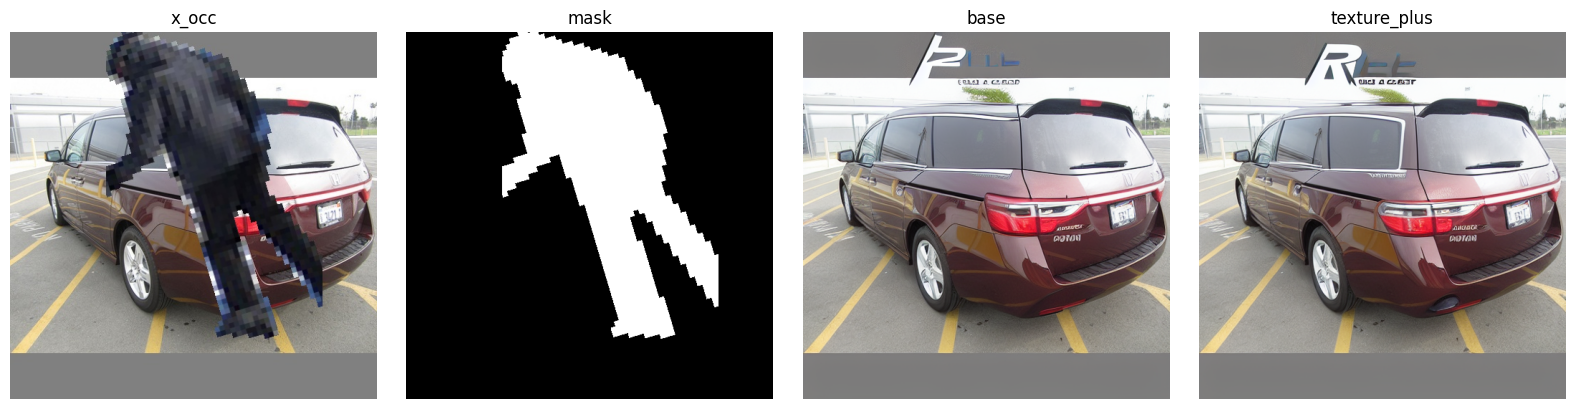

Using prompt: a car, realistic, high quality, detailed
Using negative: blurry, distorted, artifacts


In [39]:
import matplotlib.pyplot as plt

PROMPT_TRIALS = [
    {"name": "base", "prompt": "a car, realistic, high quality, detailed", "negative": "blurry, distorted, artifacts"},
    {"name": "texture_plus", "prompt": "a realistic car, high quality, detailed paint texture, natural lighting", "negative": "blurry, plastic texture, oversaturated, artifacts"},
]

sample_row = test_df.sample(1, random_state=SEED).iloc[0]
img_occ  = Image.open(OCC_DIR  / sample_row["x_occ"]).convert("RGB").resize((512, 512))
img_mask = Image.open(MASK_DIR / sample_row["mask"]).convert("L").resize((512, 512))
img_gt   = Image.open(GT_DIR   / sample_row["x_gt"]).convert("RGB").resize((512, 512))

fig, axes = plt.subplots(1, len(PROMPT_TRIALS) + 2, figsize=(4 * (len(PROMPT_TRIALS) + 2), 4))
axes[0].imshow(img_occ); axes[0].set_title("x_occ")
axes[1].imshow(img_mask, cmap="gray"); axes[1].set_title("mask")
for i, cfg in enumerate(PROMPT_TRIALS, start=2):
    pred = inpaint(img_occ, img_mask, cfg["prompt"], steps=NUM_STEPS,
                   negative_prompt=cfg["negative"], guidance_scale=GUIDANCE, seed=SEED)
    axes[i].imshow(pred); axes[i].set_title(cfg["name"])
for ax in axes:
    ax.axis("off")
plt.tight_layout(); plt.show()

PROMPT = PROMPT_TRIALS[0]["prompt"]
NEG_PROMPT = PROMPT_TRIALS[0]["negative"]
print("Using prompt:", PROMPT)
print("Using negative:", NEG_PROMPT)

In [40]:
from tqdm.auto import tqdm
import time


def run_baseline_inference(df: pd.DataFrame, batch_size: int = 4):
    rows = []
    t0 = time.perf_counter()

    for p in EVAL_GT_DIR.glob("*.png"): p.unlink()
    for p in EVAL_PRED_DIR.glob("*.png"): p.unlink()

    for i in tqdm(range(0, len(df), batch_size), desc="Baseline inference"):
        chunk = df.iloc[i:i + batch_size]
        images, masks, stems = [], [], []
        for _, r in chunk.iterrows():
            images.append(Image.open(OCC_DIR / r["x_occ"]).convert("RGB").resize((512, 512)))
            masks.append(Image.open(MASK_DIR / r["mask"]).convert("L").resize((512, 512)))
            stems.append(r.stem)

        prompts = [PROMPT] * len(images)
        negs = [NEG_PROMPT] * len(images)
        generators = [torch.Generator(device=DEVICE).manual_seed(SEED + i + j) for j in range(len(images))]

        with torch.no_grad():
            if DEVICE == "cuda":
                with torch.autocast("cuda"):
                    outs = pipe(prompt=prompts, negative_prompt=negs, image=images, mask_image=masks,
                                num_inference_steps=NUM_STEPS, guidance_scale=GUIDANCE, generator=generators).images
            else:
                outs = pipe(prompt=prompts, negative_prompt=negs, image=images, mask_image=masks,
                            num_inference_steps=NUM_STEPS, guidance_scale=GUIDANCE, generator=generators).images

        for (_, r), pred, stem in zip(chunk.iterrows(), outs, stems):
            gt = Image.open(GT_DIR / r["x_gt"]).convert("RGB").resize((512, 512))
            pred_path = PRED_DIR / f"{stem}.png"
            pred.save(pred_path)
            gt.save(EVAL_GT_DIR / f"{stem}.png")
            pred.save(EVAL_PRED_DIR / f"{stem}.png")

            rows.append({
                "stem": stem,
                "x_gt": r.x_gt,
                "x_occ": r.x_occ,
                "mask_file": r.mask,
                "pred": pred_path.name,
                "occlusion_ratio": float(r.occlusion_ratio),
            })

    elapsed = time.perf_counter() - t0
    return pd.DataFrame(rows), elapsed


pred_df, infer_elapsed = run_baseline_inference(test_df, batch_size=BATCH_SIZE)
pred_df.to_csv(REPORT_DIR / "baseline_predictions.csv", index=False)
print(f"Done: {len(pred_df):,} images | {infer_elapsed/60:.2f} min")

Baseline inference:   0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

...

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

Done: 200 images | 13.01 min


In [42]:
import cv2
import lpips
from skimage.metrics import structural_similarity as ssim
from cleanfid import fid

lpips_model = lpips.LPIPS(net="alex").to(DEVICE)
lpips_model.eval()


def masked_ssim(gt_rgb: np.ndarray, pred_rgb: np.ndarray, mask01: np.ndarray) -> float:
    gt_f = gt_rgb.astype(np.float32) / 255.0
    pr_f = pred_rgb.astype(np.float32) / 255.0
    _, ssim_map = ssim(gt_f, pr_f, channel_axis=2, data_range=1.0, full=True)
    m = mask01.astype(bool)
    return float(ssim_map[m].mean()) if m.sum() > 0 else float(ssim_map.mean())


def masked_lpips(gt_rgb: np.ndarray, pred_rgb: np.ndarray, mask01: np.ndarray) -> float:
    m = mask01.astype(np.float32)[..., None]
    gt_m = (gt_rgb.astype(np.float32) * m).astype(np.uint8)
    pr_m = (pred_rgb.astype(np.float32) * m).astype(np.uint8)
    gt_t = torch.from_numpy(gt_m).permute(2, 0, 1).unsqueeze(0).float() / 127.5 - 1.0
    pr_t = torch.from_numpy(pr_m).permute(2, 0, 1).unsqueeze(0).float() / 127.5 - 1.0
    gt_t, pr_t = gt_t.to(DEVICE), pr_t.to(DEVICE)
    with torch.no_grad():
        return float(lpips_model(gt_t, pr_t).item())


metric_rows = []
for _, r in tqdm(pred_df.iterrows(), total=len(pred_df), desc="Compute SSIM/LPIPS"):
    gt = cv2.cvtColor(cv2.imread(str(GT_DIR   / r["x_gt"])),  cv2.COLOR_BGR2RGB)
    pr = cv2.cvtColor(cv2.imread(str(PRED_DIR / r["pred"])),  cv2.COLOR_BGR2RGB)

    mk_path = MASK_DIR / f"{r['stem']}.png"
    mk = cv2.imread(str(mk_path), cv2.IMREAD_GRAYSCALE)

    mk01 = (mk > 127).astype(np.uint8)

    metric_rows.append({
        "stem"            : r["stem"],
        "occlusion_ratio" : r["occlusion_ratio"],
        "ssim"            : masked_ssim(gt, pr, mk01),
        "lpips"           : masked_lpips(gt, pr, mk01),
    })
metric_df = pd.DataFrame(metric_rows)
fid_value = fid.compute_fid(str(EVAL_GT_DIR), str(EVAL_PRED_DIR), mode="clean")

summary = {
    "config": "A_SD_only",
    "model": MODEL_ID,
    "scheduler": pipe.scheduler.__class__.__name__,
    "num_test_images": int(len(metric_df)),
    "prompt": PROMPT,
    "negative_prompt": NEG_PROMPT,
    "steps": int(NUM_STEPS),
    "guidance": float(GUIDANCE),
    "ssim_mean": float(metric_df["ssim"].mean()),
    "lpips_mean": float(metric_df["lpips"].mean()),
    "fid": float(fid_value),
    "inference_minutes": float(infer_elapsed / 60.0),
}

metric_df.to_csv(REPORT_DIR / "baseline_metrics_per_image.csv", index=False)
pd.DataFrame([summary]).to_csv(REPORT_DIR / "baseline_summary.csv", index=False)

print(pd.DataFrame([summary]))

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth


Compute SSIM/LPIPS:   0%|          | 0/200 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 12 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


compute FID between two folders
Found 200 images in the folder /kaggle/working/baseline_sd2/eval_gt_200



FID eval_gt_200 :   0%|          | 0/7 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 12 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()

FID eval_gt_200 : 100%|██████████| 7/7 [00:04<00:00,  1.48it/s]


Found 200 images in the folder /kaggle/working/baseline_sd2/eval_pred_200



FID eval_pred_200 : 100%|██████████| 7/7 [00:03<00:00,  2.06it/s]


      config                                 model  \
0  A_SD_only  runwayml/stable-diffusion-inpainting   

                     scheduler  num_test_images  \
0  DPMSolverMultistepScheduler              200   

                                     prompt               negative_prompt  \
0  a car, realistic, high quality, detailed  blurry, distorted, artifacts   

   steps  guidance  ssim_mean  lpips_mean        fid  inference_minutes  
0     20       7.5   0.427649    0.101127  35.673115          13.007884  


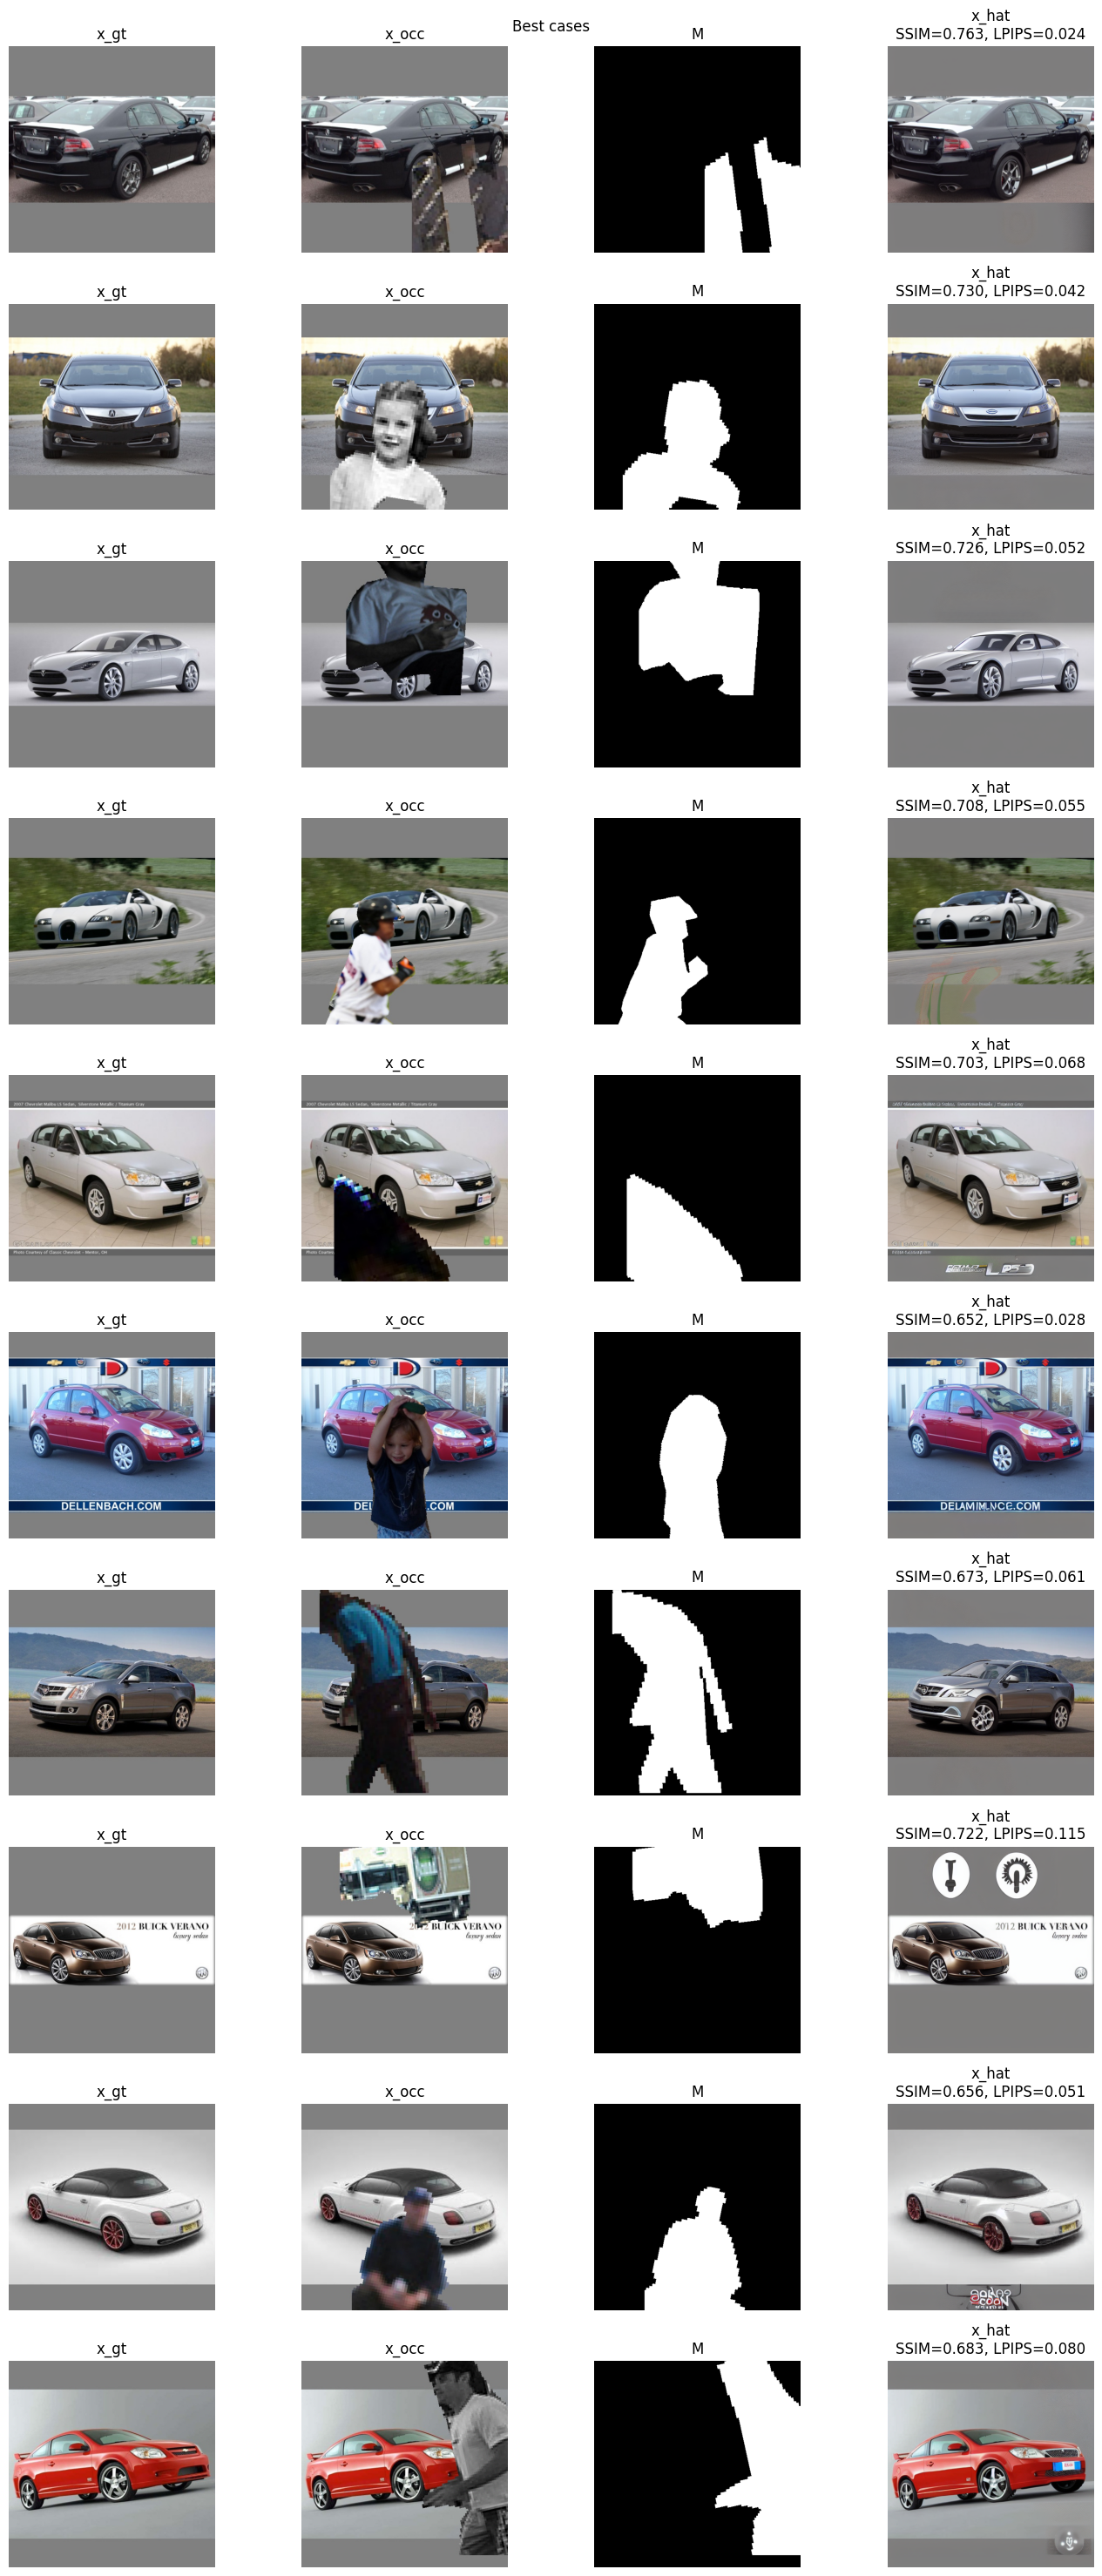

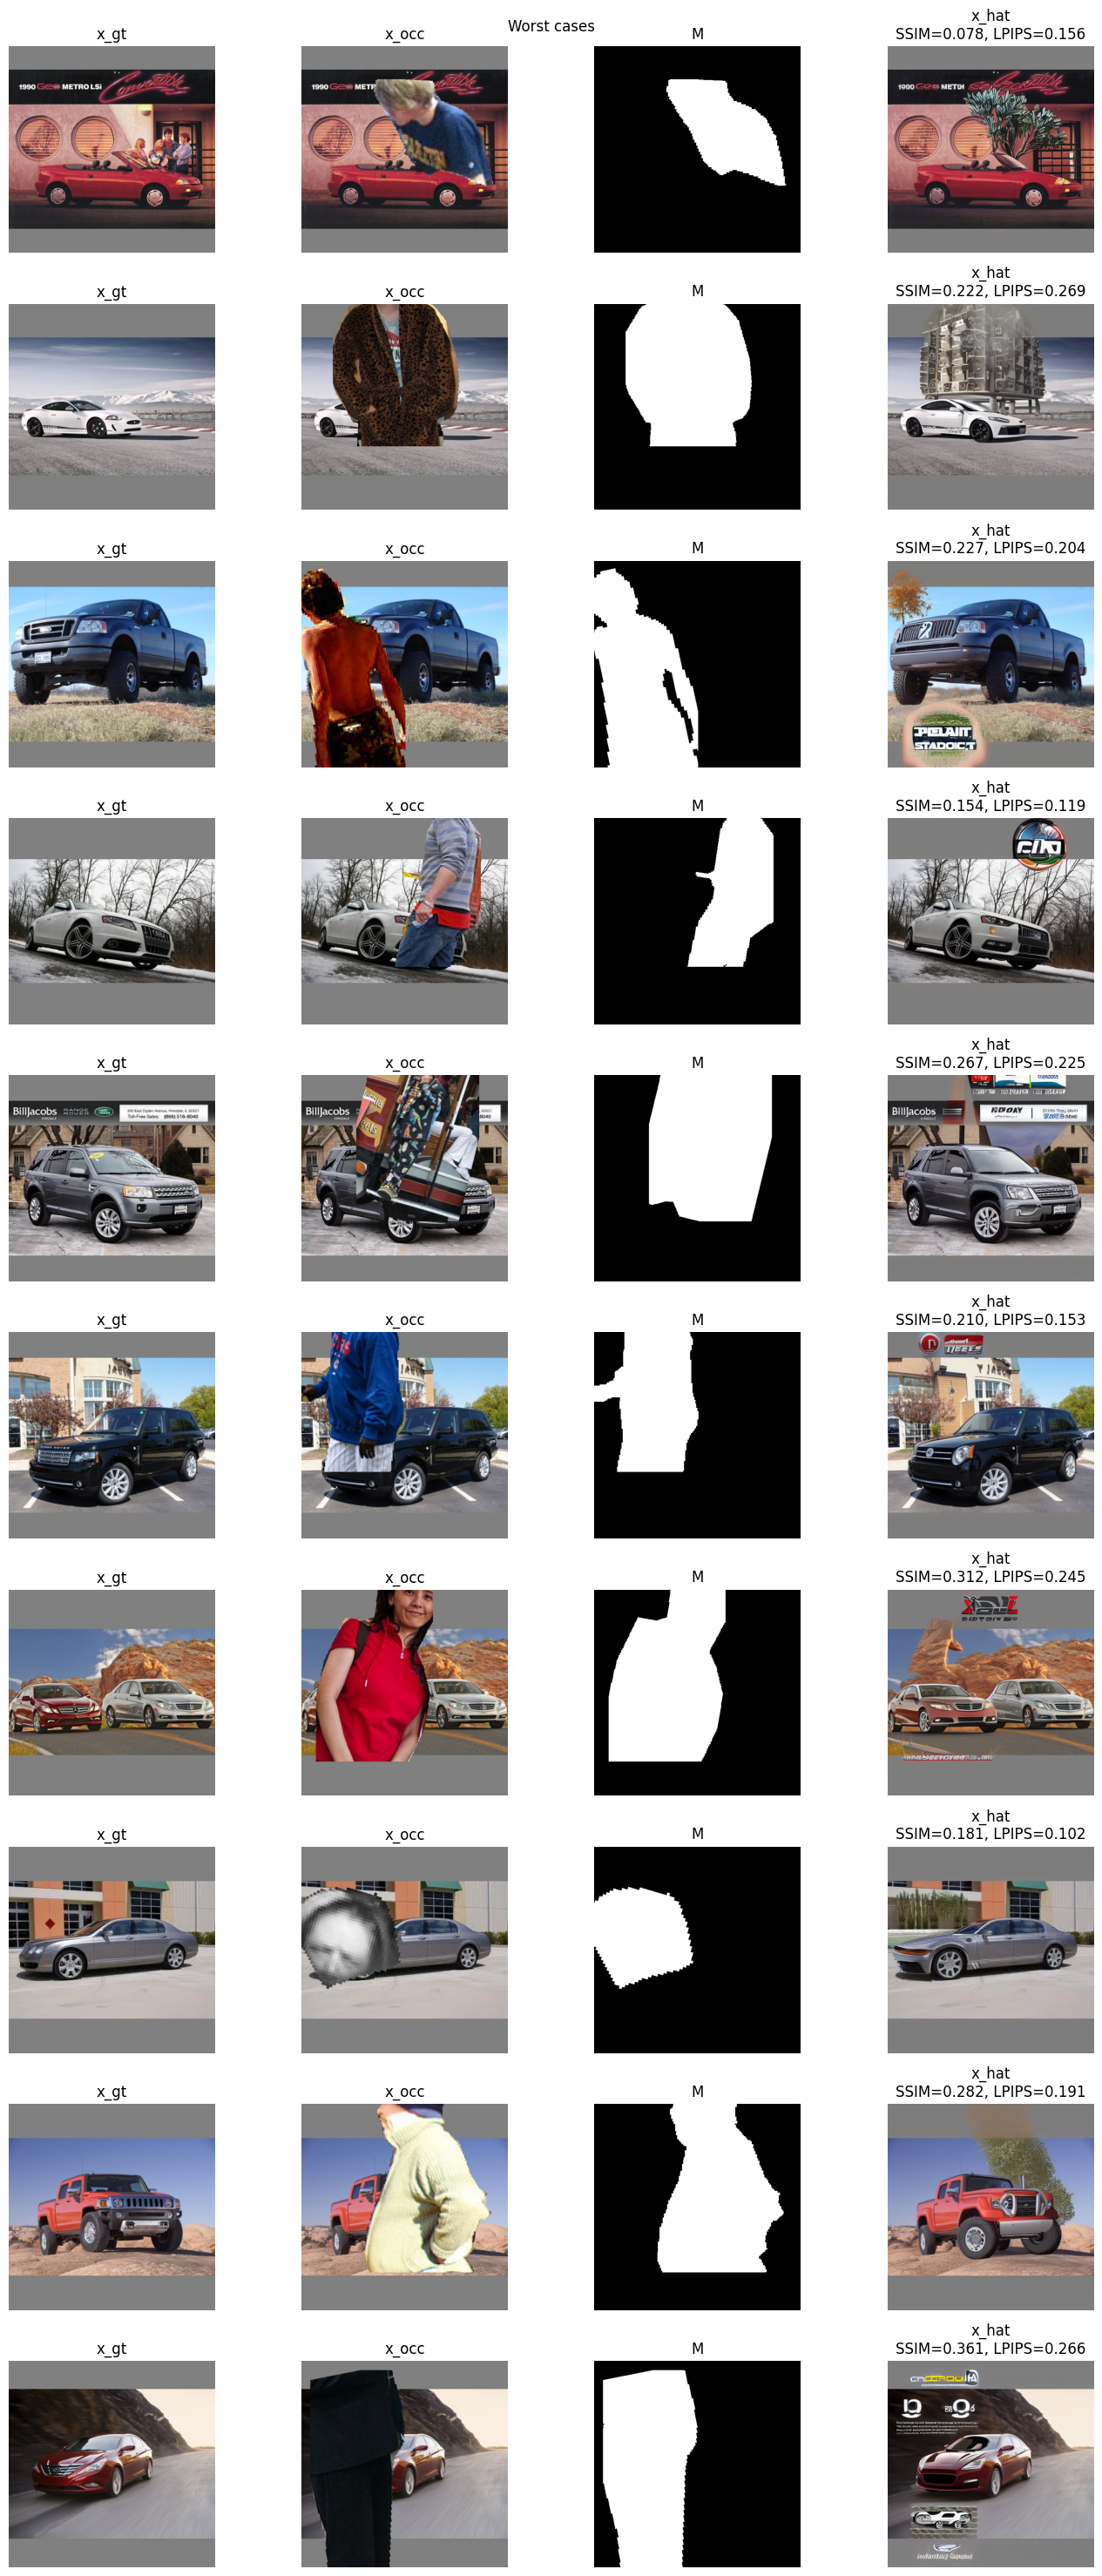

In [44]:
import matplotlib.pyplot as plt

analysis_df = metric_df.copy()
analysis_df["score"] = analysis_df["ssim"] - analysis_df["lpips"]
best20  = analysis_df.sort_values("score", ascending=False).head(20)
worst20 = analysis_df.sort_values("score", ascending=True).head(20)
best20.to_csv(REPORT_DIR  / "best20_cases.csv",  index=False)
worst20.to_csv(REPORT_DIR / "worst20_cases.csv", index=False)

def show_cases(case_df: pd.DataFrame, title: str, n_show: int = 10):
    n = min(n_show, len(case_df))
    fig, axes = plt.subplots(n, 4, figsize=(14, 3 * n))
    if n == 1:
        axes = np.expand_dims(axes, axis=0)

    for i, (_, row) in enumerate(case_df.head(n).iterrows()):
        stem = row["stem"]

        gt   = Image.open(EVAL_GT_DIR   / f"{stem}.png").convert("RGB")
        pr   = Image.open(EVAL_PRED_DIR / f"{stem}.png").convert("RGB")

        rr   = pred_df[pred_df["stem"] == stem].iloc[0]
        occ  = Image.open(OCC_DIR  / rr["x_occ"]).convert("RGB")
        mask = Image.open(MASK_DIR / f"{stem}.png").convert("L")  # dùng stem, tránh rr["mask"]

        axes[i, 0].imshow(gt);                axes[i, 0].set_title("x_gt")
        axes[i, 1].imshow(occ);               axes[i, 1].set_title("x_occ")
        axes[i, 2].imshow(mask, cmap="gray"); axes[i, 2].set_title("M")
        axes[i, 3].imshow(pr);                axes[i, 3].set_title(
            f"x_hat\nSSIM={row['ssim']:.3f}, LPIPS={row['lpips']:.3f}"
        )
        for j in range(4):
            axes[i, j].axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

show_cases(best20,  "Best cases",  n_show=10)
show_cases(worst20, "Worst cases", n_show=10)

In [45]:
ablation_row = {
    "config": "A_SD_only",
    "model"    : "runwayml/stable-diffusion-inpainting",
    "SSIM": summary["ssim_mean"],
    "LPIPS": summary["lpips_mean"],
    "FID": summary["fid"],
    "num_test": summary["num_test_images"],
    "steps": summary["steps"],
    "guidance": summary["guidance"],
    "scheduler": summary["scheduler"],
}

pd.DataFrame([ablation_row]).to_csv(REPORT_DIR / "ablation_row_baseline.csv", index=False)
print("Saved:", REPORT_DIR / "ablation_row_baseline.csv")
pd.DataFrame([ablation_row])

Saved: /kaggle/working/baseline_sd2/reports/ablation_row_baseline.csv


,config,model,SSIM,LPIPS,FID,num_test,steps,guidance,scheduler
0,A_SD_only,runwayml/stable-diffusion-inpainting,0.427649,0.101127,35.673115,200,20,7.5,DPMSolverMultistepScheduler


In [47]:
import subprocess

if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()
    r = test_df.iloc[0]
    img_occ  = Image.open(OCC_DIR  / r["x_occ"]).convert("RGB").resize((512, 512))
    img_mask = Image.open(MASK_DIR / f"{r['stem']}.png").convert("L").resize((512, 512))

    _ = inpaint(img_occ, img_mask, PROMPT, steps=10,
                negative_prompt=NEG_PROMPT, guidance_scale=GUIDANCE, seed=SEED)

    peak_mb = torch.cuda.max_memory_allocated() / 1024**2
    print(f"Peak VRAM (10 steps, 1 image): {peak_mb:.0f} MiB ({peak_mb/1024:.2f} GiB)")
    print(f"xFormers enabled: {xformers_ok}")

    try:
        smi = subprocess.check_output(
            ["nvidia-smi", "--query-gpu=name,memory.total,memory.used,memory.free",
             "--format=csv,noheader,nounits"],
            stderr=subprocess.DEVNULL,
        ).decode().strip()
        print("nvidia-smi:\n" + smi)
    except Exception:
        print("Không đọc được nvidia-smi")
else:
    print("No CUDA GPU")

  0%|          | 0/10 [00:00<?, ?it/s]

Peak VRAM (10 steps, 1 image): 2939 MiB (2.87 GiB)
xFormers enabled: True
nvidia-smi:
Tesla T4, 15360, 3933, 10980
Tesla T4, 15360, 815, 14098
